<h1>Princy Pandya 23BCE207<br>
Yamini Pambhar 23BCE204</h1>

<h1>DAV Innovative Assignment</h1>

# 📑 Report on Food Delivery Time Prediction Dataset

## 1. Domain
The dataset belongs to the *Food Delivery and Logistics* domain. It is part of the *service industry* and is directly related to *Operations Research, Supply Chain Management, and Data Science applications. The main focus is to predict the **delivery time* of food orders.

---

## 2. Stakeholders
- *Food Delivery Companies* (Zomato, Swiggy, UberEats, DoorDash)  
- *Delivery Partners / Riders*  
- *Customers*  
- *Restaurants*  
- *Data Scientists and Analysts*  
- *Business Managers / Operations Teams*

---

## 3. About the Dataset
The dataset contains historical records of food orders and their delivery times. It includes:  
- Order details (time, ID, location)  
- Restaurant details (preparation time, distance to customer)  
- Delivery factors (traffic conditions, rider availability)  
- *Target variable:* Delivery Time  

---

## 4. Applications and Benefits
- Accurate ETA Prediction → Improves customer satisfaction  
- Optimized Rider Assignment → Reduces idle time  
- Bottleneck Analysis → Identifies causes of delays  
- Business Insights → Helps in staffing and operations planning  

---

## 5. Data Quality Considerations
- Handle missing values (mean/median/mode)  
- Treat outliers (unrealistic delivery times)  
- Encode categorical variables for ML models  
- Normalize continuous variables if needed  

---

In [326]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde

In [327]:
data=pd.read_csv('Food_Delivery_Time_Prediction_custom_nulls.csv')

In [403]:
data.shape

(230, 15)

In [328]:
d=data.copy()
d.head()

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.57,Rainy,Medium,4.0,Medium,Afternoon,NaN,4.1,3.0,26.22,1321.10,81.54
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.32,Cloudy,Medium,8.0,Low,Night,Car,4.5,4.2,62.61,152.21,29.02
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.95,Snowy,Medium,9.0,High,Night,Bike,3.3,3.4,48.43,1644.38,64.17
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.79,Cloudy,Low,2.0,Medium,Evening,Bike,NaN,3.7,111.63,541.25,79.23
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.72,Rainy,High,6.0,Low,NaN,Bike,3.5,2.8,32.38,619.81,2.34


In [329]:
d.isnull().sum()

Order_ID                       8
Customer_Location              2
Restaurant_Location            3
Distance                      14
Weather_Conditions             8
Traffic_Conditions            15
Delivery_Person_Experience    16
Order_Priority                 6
Order_Time                    20
Vehicle_Type                  18
Restaurant_Rating             16
Customer_Rating               17
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

<h3>Correcting Null values and incorrect data</h3>

dropping duplicate and empty rows in Order_ID column

In [330]:
d.dropna(subset=['Order_ID'], inplace=True)
d.drop_duplicates(subset='Order_ID', keep='first', inplace=True)

d.isnull().sum()

Order_ID                       0
Customer_Location              2
Restaurant_Location            3
Distance                      14
Weather_Conditions             8
Traffic_Conditions            15
Delivery_Person_Experience    16
Order_Priority                 6
Order_Time                    20
Vehicle_Type                  18
Restaurant_Rating             16
Customer_Rating               17
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

drop incorrect data for Order_ID column<br>
if inplace=True not used then the changes will not be applied to the original dataframe 


In [331]:
d.drop(d[ d['Order_ID'].str.match(r'^ORD\d{4}$')==False ].index, inplace=True) 

drop rows with null values in Customer_Location column

In [332]:
d.dropna(subset=['Customer_Location'], inplace=True)

d.isnull().sum()

Order_ID                       0
Customer_Location              0
Restaurant_Location            3
Distance                      14
Weather_Conditions             8
Traffic_Conditions            15
Delivery_Person_Experience    16
Order_Priority                 6
Order_Time                    20
Vehicle_Type                  18
Restaurant_Rating             16
Customer_Rating               17
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

Dropping rows with null values in column Restaurant_location

In [333]:
d.dropna(subset=['Restaurant_Location'], inplace=True)

d.isnull().sum()

Order_ID                       0
Customer_Location              0
Restaurant_Location            0
Distance                      14
Weather_Conditions             8
Traffic_Conditions            15
Delivery_Person_Experience    16
Order_Priority                 6
Order_Time                    20
Vehicle_Type                  18
Restaurant_Rating             16
Customer_Rating               17
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

Replacing null values in Distance by calculating distance between Restaurant and Customer Location

In [334]:
def haversine(coord1, coord2):
    lat1, lon1 = coord1
    lat2, lon2 = coord2
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1 
    dlon = lon2 - lon1 
    a = np.sin(dlat / 2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2.0)**2
    c = 2 * np.arcsin(np.sqrt(a)) 
    r = 6371 
    return c * r

def fill_distance(row):
    if pd.isna(row['Distance']):
        customer_location = tuple(map(float, row['Customer_Location'].strip('()').split(', ')))
        restaurant_location = tuple(map(float, row['Restaurant_Location'].strip('()').split(', ')))
        return haversine(customer_location, restaurant_location)
    else:
        return row['Distance']

d['Distance'] = d.apply(fill_distance, axis=1)

d.isnull().sum()


Order_ID                       0
Customer_Location              0
Restaurant_Location            0
Distance                       0
Weather_Conditions             8
Traffic_Conditions            15
Delivery_Person_Experience    16
Order_Priority                 6
Order_Time                    20
Vehicle_Type                  18
Restaurant_Rating             16
Customer_Rating               17
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

Handling incorrect values in Distance : distance values should be greater than 0

In [335]:
d['Distance'] = d['Distance'].abs()

fill null values in Weather_Conditions with 'Cloudy'

In [336]:
d['Weather_Conditions'].fillna('Medium')

0       Rainy
1      Cloudy
2       Snowy
3      Cloudy
4       Rainy
        ...  
225     Snowy
226     Snowy
227     Rainy
228     Rainy
229     Rainy
Name: Weather_Conditions, Length: 217, dtype: object

Traffic_Conditions values should be one of the following : Rainy, Cloudy, Snowy

In [337]:
valid_traffic_conditions = ['Rainy', 'Cloudy', 'Snowy']
d.loc[~d['Weather_Conditions'].isin(valid_traffic_conditions), 'Weather_Conditions'] = 'Cloudy'

d.isnull().sum()

Order_ID                       0
Customer_Location              0
Restaurant_Location            0
Distance                       0
Weather_Conditions             0
Traffic_Conditions            15
Delivery_Person_Experience    16
Order_Priority                 6
Order_Time                    20
Vehicle_Type                  18
Restaurant_Rating             16
Customer_Rating               17
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

fill null values in Traffic_Conditions with 'Medium'

In [338]:
d['Traffic_Conditions'] = d['Traffic_Conditions'].fillna('Medium')

Traffic_Conditions values should be one of the following : Low, Medium, High

In [339]:
valid_traffic_conditions = ['Low', 'Medium', 'High']
d.loc[~d['Traffic_Conditions'].isin(valid_traffic_conditions), 'Traffic_Conditions'] = 'Medium'

d.isnull().sum()


Order_ID                       0
Customer_Location              0
Restaurant_Location            0
Distance                       0
Weather_Conditions             0
Traffic_Conditions             0
Delivery_Person_Experience    16
Order_Priority                 6
Order_Time                    20
Vehicle_Type                  18
Restaurant_Rating             16
Customer_Rating               17
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

Deliver_Person_Experience values should be positive and non-zero

In [340]:
mean_exp = np.mean(d.loc[d['Delivery_Person_Experience'] > 0, 'Delivery_Person_Experience'])
d['Delivery_Person_Experience'].fillna(mean_exp, inplace=True)

d.isnull().sum()

C:\Users\Princy Pandya\AppData\Local\Temp\ipykernel_9808\2350976382.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d['Delivery_Person_Experience'].fillna(mean_exp, inplace=True)


Order_ID                       0
Customer_Location              0
Restaurant_Location            0
Distance                       0
Weather_Conditions             0
Traffic_Conditions             0
Delivery_Person_Experience     0
Order_Priority                 6
Order_Time                    20
Vehicle_Type                  18
Restaurant_Rating             16
Customer_Rating               17
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

Handling incorrect data in column 'Delivery_Person_Experience'

In [341]:
d.loc[d['Delivery_Person_Experience'] <= 0, 'Delivery_Person_Experience'] = mean_exp

fill null values in Order_Priority with 'Medium'

In [342]:
d['Order_Priority'].fillna('Medium')

0      Medium
1         Low
2        High
3      Medium
4         Low
        ...  
225       Low
226      High
227      High
228    Medium
229      High
Name: Order_Priority, Length: 217, dtype: object

Order_Priority values should be one of the following L Low, Medium, High

In [343]:
valid_order_priority = ['Low', 'Medium', 'High']
d.loc[~d['Order_Priority'].isin(valid_order_priority), 'Order_Priority'] = 'Medium'

d.isnull().sum()

Order_ID                       0
Customer_Location              0
Restaurant_Location            0
Distance                       0
Weather_Conditions             0
Traffic_Conditions             0
Delivery_Person_Experience     0
Order_Priority                 0
Order_Time                    20
Vehicle_Type                  18
Restaurant_Rating             16
Customer_Rating               17
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

fill null values in Order_Time with 'Night'

In [344]:
d['Order_Time'].fillna('Night')

d.isnull().sum()

Order_ID                       0
Customer_Location              0
Restaurant_Location            0
Distance                       0
Weather_Conditions             0
Traffic_Conditions             0
Delivery_Person_Experience     0
Order_Priority                 0
Order_Time                    20
Vehicle_Type                  18
Restaurant_Rating             16
Customer_Rating               17
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

Order_Time values should be one of the following : Afternoon, Night, Evening, Morning

In [345]:
valid_order_time = ['Afternoon', 'Night', 'Evening', 'Morning']
d.loc[~d['Order_Time'].isin(valid_order_time), 'Order_Time'] = 'Night'

fill null values in Vehicle_Type with 'Bike'

In [346]:
d['Vehicle_Type'].fillna('Bike')

d.isnull().sum()

Order_ID                       0
Customer_Location              0
Restaurant_Location            0
Distance                       0
Weather_Conditions             0
Traffic_Conditions             0
Delivery_Person_Experience     0
Order_Priority                 0
Order_Time                     0
Vehicle_Type                  18
Restaurant_Rating             16
Customer_Rating               17
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

Vehicle_Type values should be one of the following : Car, Bike, Bicycle

In [347]:
valid_vehicle_type = ['Car', 'Bike', 'Bicycle']
d.loc[~d['Vehicle_Type'].isin(valid_vehicle_type), 'Vehicle_Type'] = 'Bike'

Replace NaN values with the mean rating

In [348]:
mean_rating = d['Restaurant_Rating'].mean()
d['Restaurant_Rating'].fillna(mean_rating, inplace=True)

d.isnull().sum()

C:\Users\Princy Pandya\AppData\Local\Temp\ipykernel_9808\2297420207.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d['Restaurant_Rating'].fillna(mean_rating, inplace=True)


Order_ID                       0
Customer_Location              0
Restaurant_Location            0
Distance                       0
Weather_Conditions             0
Traffic_Conditions             0
Delivery_Person_Experience     0
Order_Priority                 0
Order_Time                     0
Vehicle_Type                   0
Restaurant_Rating              0
Customer_Rating               17
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

Restaurant_Rating values all greater than 0<br>
Restaurant_Rating values all should be less than or equal to 5

In [349]:
d.loc[(d['Restaurant_Rating'] <= 0) | (d['Restaurant_Rating'] > 5), 'Restaurant_Rating'] = mean_rating


Replace NaN values with the mean rating

In [350]:
mean_rating = d['Customer_Rating'].mean()
d['Customer_Rating'].fillna(mean_rating, inplace=True)

d.isnull().sum()

C:\Users\Princy Pandya\AppData\Local\Temp\ipykernel_9808\2656937709.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d['Customer_Rating'].fillna(mean_rating, inplace=True)


Order_ID                       0
Customer_Location              0
Restaurant_Location            0
Distance                       0
Weather_Conditions             0
Traffic_Conditions             0
Delivery_Person_Experience     0
Order_Priority                 0
Order_Time                     0
Vehicle_Type                   0
Restaurant_Rating              0
Customer_Rating                0
Delivery_Time                  8
Order_Cost                    12
Tip_Amount                    17
dtype: int64

Customer_Rating values all greater than 0<br>
Customer_Rating values all should be less than or equal to 5

In [351]:
d.loc[d['Customer_Rating']<=0,'Customer_Rating']=np.mean(d[d['Customer_Rating']>0]['Customer_Rating'])
d.loc[d['Customer_Rating']>5,'Customer_Rating']=np.mean(d[(d['Customer_Rating'] >= 2.6) & (d['Customer_Rating'] < 5)]['Customer_Rating'])

Delivery_Time null values replace with mean

In [352]:
mean_rating = d['Delivery_Time'].mean()
d['Delivery_Time'].fillna(mean_rating, inplace=True)

d.isnull().sum()

C:\Users\Princy Pandya\AppData\Local\Temp\ipykernel_9808\2132274237.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d['Delivery_Time'].fillna(mean_rating, inplace=True)


Order_ID                       0
Customer_Location              0
Restaurant_Location            0
Distance                       0
Weather_Conditions             0
Traffic_Conditions             0
Delivery_Person_Experience     0
Order_Priority                 0
Order_Time                     0
Vehicle_Type                   0
Restaurant_Rating              0
Customer_Rating                0
Delivery_Time                  0
Order_Cost                    12
Tip_Amount                    17
dtype: int64

Delivery_Time values all greater than 0

In [353]:
d['Delivery_Time'] = d['Delivery_Time'].abs()

Order_Cost null values replace with mean

In [354]:
mean_rating = d['Order_Cost'].mean()
d['Order_Cost'].fillna(mean_rating, inplace=True)

d.isnull().sum()

C:\Users\Princy Pandya\AppData\Local\Temp\ipykernel_9808\2610004702.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d['Order_Cost'].fillna(mean_rating, inplace=True)


Order_ID                       0
Customer_Location              0
Restaurant_Location            0
Distance                       0
Weather_Conditions             0
Traffic_Conditions             0
Delivery_Person_Experience     0
Order_Priority                 0
Order_Time                     0
Vehicle_Type                   0
Restaurant_Rating              0
Customer_Rating                0
Delivery_Time                  0
Order_Cost                     0
Tip_Amount                    17
dtype: int64

Order_Cost values all greater than 0

In [355]:
d['Order_Cost'] = d['Order_Cost'].abs()

Tip_Amount null values replacing with mean

In [356]:
mean_rating = d['Tip_Amount'].mean()
d['Tip_Amount'].fillna(mean_rating, inplace=True)

d.isnull().sum()

C:\Users\Princy Pandya\AppData\Local\Temp\ipykernel_9808\3934803463.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  d['Tip_Amount'].fillna(mean_rating, inplace=True)


Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

Tip_Amount values all greater than 0

In [357]:
d['Tip_Amount'] = d['Tip_Amount'].abs()

In [358]:
d

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.570000,Rainy,Medium,4.000000,Medium,Afternoon,Bike,4.100000,3.000,26.220000,1321.10,81.540000
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.320000,Cloudy,Medium,8.000000,Low,Night,Car,4.500000,4.200,62.610000,152.21,29.020000
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.950000,Snowy,Medium,9.000000,High,Night,Bike,3.300000,3.400,48.430000,1644.38,64.170000
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.790000,Cloudy,Low,2.000000,Medium,Evening,Bike,3.799502,3.700,111.630000,541.25,79.230000
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.720000,Rainy,High,6.000000,Low,Night,Bike,3.500000,2.800,32.380000,619.81,2.340000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,ORD0226,"(12.151614, 83.536485)","(21.417753, 78.073953)",5.180000,Snowy,High,24.465192,Low,Morning,Bike,3.000000,3.671,197.981299,619.81,69.600000
226,ORD0227,"(13.429301, 78.290829)","(13.951955, 81.113552)",8.080000,Snowy,Low,5.239723,High,Evening,Bike,4.500000,4.200,338.971199,300.01,84.080000
227,ORD0228,"(12.094598, 84.480602)","(12.500315, 80.8749)",394.321632,Rainy,Low,3.000000,High,Afternoon,Bicycle,2.900000,2.600,115.690000,223.60,310.872008
228,ORD0229,"(20.974232, 80.728561)","(13.820324, 85.504206)",13.480000,Rainy,Medium,8.000000,Medium,Evening,Car,4.700000,2.800,78.658522,1767.21,310.872008


In [359]:
d.isnull().sum()

Order_ID                      0
Customer_Location             0
Restaurant_Location           0
Distance                      0
Weather_Conditions            0
Traffic_Conditions            0
Delivery_Person_Experience    0
Order_Priority                0
Order_Time                    0
Vehicle_Type                  0
Restaurant_Rating             0
Customer_Rating               0
Delivery_Time                 0
Order_Cost                    0
Tip_Amount                    0
dtype: int64

In [360]:
d.to_csv('Food_Delivery_Time_Prediction_without_null_values.csv', index=False)

In [361]:
# weather_map = {'Sunny': 0, 'Rainy': 1, 'Snowy': 2, 'Cloudy': 3}
# d['Weather_Conditions'] = d['Weather_Conditions'].map(weather_map)

# traffic_map = {'Low': 0, 'Medium': 1, 'High': 2}
# d['Traffic_Conditions'] = d['Traffic_Conditions'].map(traffic_map)

# order_priority_map = {'Low': 0, 'Medium': 1, 'High': 2}
# d['Order_Priority'] = d['Order_Priority'].map(order_priority_map)

# order_time_map = {'Morning': 0, 'Afternoon': 1, 'Evening': 2, 'Night': 3}
# d['Order_Time'] = d['Order_Time'].map(order_time_map)

# vehicle_type_map = {'Bicycle': 0, 'Bike': 1, 'Car': 2}
# d['Vehicle_Type'] = d['Vehicle_Type'].map(vehicle_type_map)

In [362]:
d

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.570000,Rainy,Medium,4.000000,Medium,Afternoon,Bike,4.100000,3.000,26.220000,1321.10,81.540000
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.320000,Cloudy,Medium,8.000000,Low,Night,Car,4.500000,4.200,62.610000,152.21,29.020000
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.950000,Snowy,Medium,9.000000,High,Night,Bike,3.300000,3.400,48.430000,1644.38,64.170000
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.790000,Cloudy,Low,2.000000,Medium,Evening,Bike,3.799502,3.700,111.630000,541.25,79.230000
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.720000,Rainy,High,6.000000,Low,Night,Bike,3.500000,2.800,32.380000,619.81,2.340000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,ORD0226,"(12.151614, 83.536485)","(21.417753, 78.073953)",5.180000,Snowy,High,24.465192,Low,Morning,Bike,3.000000,3.671,197.981299,619.81,69.600000
226,ORD0227,"(13.429301, 78.290829)","(13.951955, 81.113552)",8.080000,Snowy,Low,5.239723,High,Evening,Bike,4.500000,4.200,338.971199,300.01,84.080000
227,ORD0228,"(12.094598, 84.480602)","(12.500315, 80.8749)",394.321632,Rainy,Low,3.000000,High,Afternoon,Bicycle,2.900000,2.600,115.690000,223.60,310.872008
228,ORD0229,"(20.974232, 80.728561)","(13.820324, 85.504206)",13.480000,Rainy,Medium,8.000000,Medium,Evening,Car,4.700000,2.800,78.658522,1767.21,310.872008


<h3>Step 2 - Exploratory Data Analysis</h3>

keepdims=True makes sure the result is always an array, even if there is only one mode.<br>
Without keepdims=True, the output might be a scalar if the input is 1D, which can sometimes cause issues in further processing.

In [363]:
dist_mean=np.mean(d['Distance'])
dist_mode=stats.mode(d['Distance'], keepdims=True).mode[0]
dist_median=np.median(d['Distance'])
dist_var=np.var(d['Distance'])

# weather_mode = stats.mode(d['Weather_Conditions'], keepdims=True).mode[0]
# weather_median = np.median(d['Weather_Conditions'])

# Traffic_mode = stats.mode(d['Traffic_Conditions'], keepdims=True).mode[0]
# Traffic_median = np.median(d['Traffic_Conditions'])

delivery_person_experience_mean=np.mean(d['Delivery_Person_Experience'])
delivery_person_experience_mode=stats.mode(d['Delivery_Person_Experience'], keepdims=True).mode[0]
delivery_person_experience_median=np.median(d['Delivery_Person_Experience'])
delivery_person_experience_var=np.var(d['Delivery_Person_Experience'])

# Order_priority_mode = stats.mode(d['Order_Priority'], keepdims=True).mode[0]
# Order_priority_median = np.median(d['Order_Priority'])

# Order_time_mode = stats.mode(d['Order_Time'], keepdims=True).mode[0]
# Order_time_median = np.median(d['Order_Time'])

# Vehicle_Type_mode = stats.mode(d['Vehicle_Type'], keepdims=True).mode[0]
# Vehicle_Type_median = np.median(d['Vehicle_Type'])

restaurant_rating_mean=np.mean(d['Restaurant_Rating'])
restaurant_rating_mode=stats.mode(d['Restaurant_Rating'], keepdims=True).mode[0]
restaurant_rating_median=np.median(d['Restaurant_Rating'])
restaurant_rating_var=np.var(d['Delivery_Person_Experience'])

customer_rating_mean=np.mean(d['Customer_Rating'])
customer_rating_mode=stats.mode(d['Customer_Rating'], keepdims=True).mode[0]
customer_rating_median=np.median(d['Customer_Rating'])
customer_rating_var=np.var(d['Customer_Rating'])

Delivery_Time_mean=np.mean(d['Delivery_Time'])
Delivery_Time_mode=stats.mode(d['Delivery_Time'], keepdims=True).mode[0]
Delivery_Time_median=np.median(d['Delivery_Time'])
Delivery_Time_var=np.var(d['Delivery_Time'])

Order_Cost_mean=np.mean(d['Order_Cost'])
Order_Cost_mode=stats.mode(d['Order_Cost'], keepdims=True).mode[0]
Order_Cost_median=np.median(d['Order_Cost'])
Order_Cost_var=np.var(d['Order_Cost'])

Tip_Amount_mean=np.mean(d['Tip_Amount'])
Tip_Amount_mode=stats.mode(d['Tip_Amount'], keepdims=True).mode[0]
Tip_Amount_median=np.median(d['Tip_Amount'])
Tip_Amount_var=np.var(d['Tip_Amount'])

In [364]:
print('Mean of Distance : ', dist_mean)
print('Median of Distance : ', dist_median)
print('Mode of Distance : ', dist_mode)
print('Variance of Distance : ', dist_var)

# print('')
# print('Mode of Weather_Conditions : ', weather_mode)
# print('Median of Weather_Conditions : ', weather_median)

# print('')
# print('Mode of Traffic_Conditions : ', Traffic_mode)
# print('Median of Traffic_Conditions : ', Traffic_median)

print('')
print('Mean of Delivery_Person_Experience : ', delivery_person_experience_mean)
print('Median of Delivery_Person_Experience : ', delivery_person_experience_median)
print('Mode of Delivery_Person_Experience : ', delivery_person_experience_mode)
print('Variance of Delivery_Person_Experience : ', delivery_person_experience_var)

# print('')
# print('Mode of Order_Priority : ', Order_priority_mode)
# print('Median of Order_Priority : ', Order_priority_median)

# print('')
# print('Mode of Order_Time : ', Order_time_mode)
# print('Median of Order_Time : ', Order_time_median)

# print('')
# print('Mode of Vehicle_Type : ', Vehicle_Type_mode)
# print('Median of Vehicle_Type : ', Vehicle_Type_median)

print('')
print('Mean of Restaurant_Rating : ', restaurant_rating_mean)
print('Median of Restaurant_Rating : ', restaurant_rating_median)
print('Mode of Restaurant_Rating : ', restaurant_rating_mode)
print('Variance of Restaurant_Rating : ', restaurant_rating_var)

print('')
print('Mean of Customer_Rating : ', customer_rating_mean)
print('Median of Customer_Rating : ', customer_rating_median)
print('Mode of Customer_Rating : ', customer_rating_mode)
print('Variance of Customer_Rating : ', customer_rating_var)

print('')
print('Mean of Delivery_Time : ', Delivery_Time_mean)
print('Median of Delivery_Time : ', Delivery_Time_median)
print('Mode of Delivery_Time : ', Delivery_Time_mode)
print('Variance of Delivery_Time : ', Delivery_Time_var)

print('')
print('Mean of Order_Cost : ', Order_Cost_mean)
print('Median of Order_Cost : ', Order_Cost_median)
print('Mode of Order_Cost : ', Order_Cost_mode)
print('Variance of Order_Cost : ', Order_Cost_var)

print('')
print('Mean of Tip_Amount : ', Tip_Amount_mean)
print('Median of Tip_Amount : ', Tip_Amount_median)
print('Mode of Tip_Amount : ', Tip_Amount_mode)
print('Variance of Tip_Amount : ', Tip_Amount_var)

Mean of Distance :  45.6430553997696
Median of Distance :  12.2
Mode of Distance :  6.09
Variance of Distance :  20344.841251975235

Mean of Delivery_Person_Experience :  5.239723193838384
Median of Delivery_Person_Experience :  5.239723193838383
Mode of Delivery_Person_Experience :  2.0
Variance of Delivery_Person_Experience :  8.163664547819923

Mean of Restaurant_Rating :  3.7995024875621883
Median of Restaurant_Rating :  3.8
Mode of Restaurant_Rating :  3.7995024875621892
Variance of Restaurant_Rating :  8.163664547819923

Mean of Customer_Rating :  3.671
Median of Customer_Rating :  3.671
Mode of Customer_Rating :  3.671
Variance of Customer_Rating :  0.44152903225806456

Mean of Delivery_Time :  76.13237201240756
Median of Delivery_Time :  72.91
Mode of Delivery_Time :  65.55888319655502
Variance of Delivery_Time :  1859.6978970494063

Mean of Order_Cost :  1180.869133463752
Median of Order_Cost :  1054.82
Mode of Order_Cost :  1026.3902162195125
Variance of Order_Cost :  690518.

Annot value in matrix greater than 0.05 both + and - then they have importance or correlation or dependancy with each other<br>
more the value more they are correlated

A negative correlation means that as one variable increases, the other decreases<br>
A positive correlation means that as one variable increases, the other also increases

Feature means column

There is a target_feature and other features<br>
If among other features if they are highly correlated (+ve) (more than 0.9 or values greater than 0.7 or 0.8) with each other then among them only one of them should be kept and drop the other(s)

A feature highly correlated with target_feature should not be removed

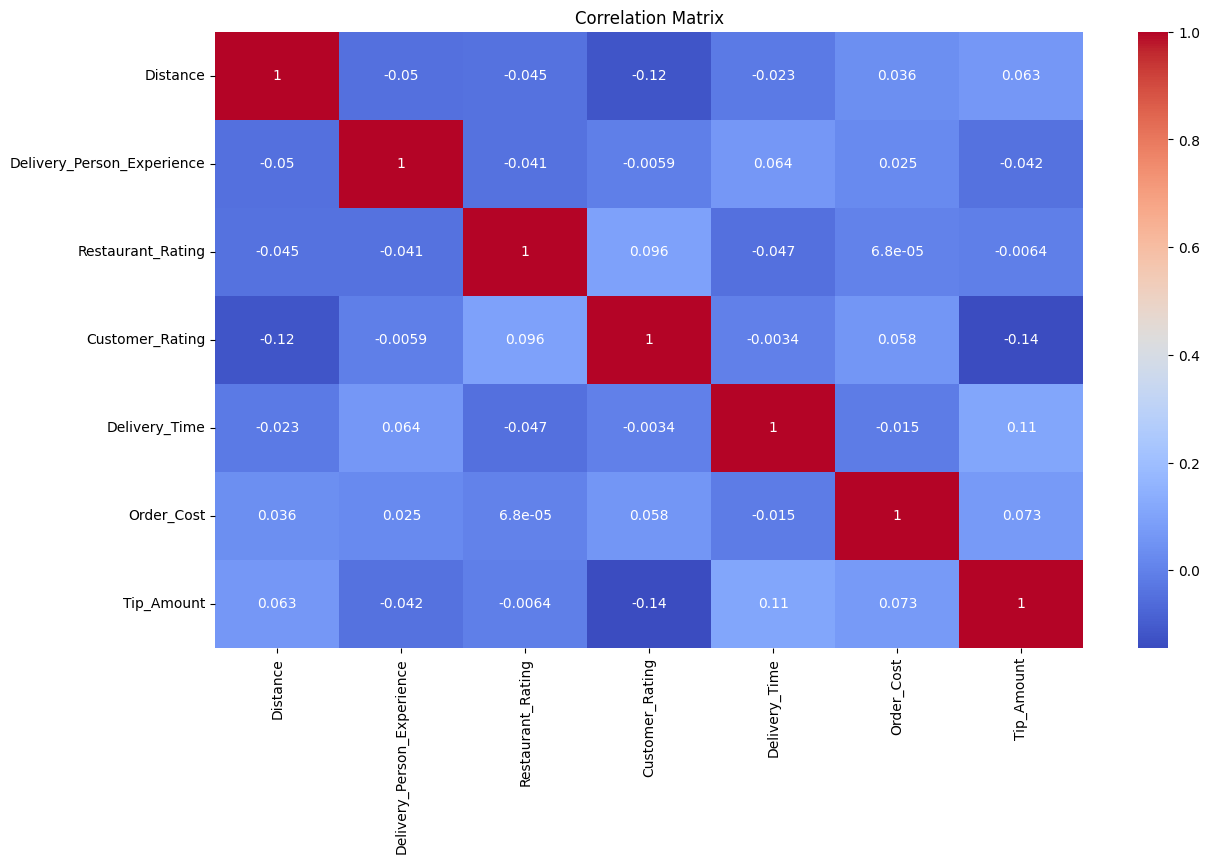

Correlation of features with Delivery_Time : 
Restaurant_Rating            -0.047197
Distance                     -0.022834
Order_Cost                   -0.015179
Customer_Rating              -0.003388
Delivery_Person_Experience    0.063659
Tip_Amount                    0.106760
Delivery_Time                 1.000000
Name: Delivery_Time, dtype: float64


In [365]:
correlation_matrix = d.corr(numeric_only=True)
plt.figure(figsize=(14, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

correlation_with_target = correlation_matrix['Delivery_Time'].sort_values()
print("Correlation of features with Delivery_Time : ")
print(correlation_with_target)

Outliers -> some values that are either too big or too small than the most of the values in that column

They affect the output soo much<br>
Output that should have come is affected

Z-score or IQR method is used to remove outliers

In [366]:
d

,Order_ID,Customer_Location,Restaurant_Location,Distance,Weather_Conditions,Traffic_Conditions,Delivery_Person_Experience,Order_Priority,Order_Time,Vehicle_Type,Restaurant_Rating,Customer_Rating,Delivery_Time,Order_Cost,Tip_Amount
0,ORD0001,"(17.030479, 79.743077)","(12.358515, 85.100083)",1.570000,Rainy,Medium,4.000000,Medium,Afternoon,Bike,4.100000,3.000,26.220000,1321.10,81.540000
1,ORD0002,"(15.398319, 86.639122)","(14.174874, 77.025606)",21.320000,Cloudy,Medium,8.000000,Low,Night,Car,4.500000,4.200,62.610000,152.21,29.020000
2,ORD0003,"(15.687342, 83.888808)","(19.594748, 82.048482)",6.950000,Snowy,Medium,9.000000,High,Night,Bike,3.300000,3.400,48.430000,1644.38,64.170000
3,ORD0004,"(20.415599, 78.046984)","(16.915906, 78.278698)",13.790000,Cloudy,Low,2.000000,Medium,Evening,Bike,3.799502,3.700,111.630000,541.25,79.230000
4,ORD0005,"(14.786904, 78.706532)","(15.206038, 86.203182)",6.720000,Rainy,High,6.000000,Low,Night,Bike,3.500000,2.800,32.380000,619.81,2.340000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
225,ORD0226,"(12.151614, 83.536485)","(21.417753, 78.073953)",5.180000,Snowy,High,24.465192,Low,Morning,Bike,3.000000,3.671,197.981299,619.81,69.600000
226,ORD0227,"(13.429301, 78.290829)","(13.951955, 81.113552)",8.080000,Snowy,Low,5.239723,High,Evening,Bike,4.500000,4.200,338.971199,300.01,84.080000
227,ORD0228,"(12.094598, 84.480602)","(12.500315, 80.8749)",394.321632,Rainy,Low,3.000000,High,Afternoon,Bicycle,2.900000,2.600,115.690000,223.60,310.872008
228,ORD0229,"(20.974232, 80.728561)","(13.820324, 85.504206)",13.480000,Rainy,Medium,8.000000,Medium,Evening,Car,4.700000,2.800,78.658522,1767.21,310.872008


To see outliers clearly using box plot

In [367]:
boxplot_columns = [
    'Distance',
    'Delivery_Person_Experience',
    'Restaurant_Rating',
    'Customer_Rating',
    'Delivery_Time',
    'Order_Cost',
    'Tip_Amount',
    'Calculated_Distance'
]

results = []

for col in boxplot_columns:
    if col in d.columns:
        col_data = d[col]
        q1 = col_data.quantile(0.25)
        q2 = col_data.quantile(0.50)
        q3 = col_data.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        results.append({
            'Column': col,
            'Q1': q1,
            'Q2 (Median)': q2,
            'Q3': q3,
            'IQR': iqr,
            'Lower Bound': lower,
            'Upper Bound': upper
        })

summary_df = pd.DataFrame(results)
print(summary_df.round(3).to_markdown(index=False))

| Column                     |     Q1 |   Q2 (Median) |      Q3 |    IQR |   Lower Bound |   Upper Bound |
|:---------------------------|-------:|--------------:|--------:|-------:|--------------:|--------------:|
| Distance                   |   7.09 |        12.2   |   20.25 |  13.16 |       -12.65  |        39.99  |
| Delivery_Person_Experience |   3    |         5.24  |    7    |   4    |        -3     |        13     |
| Restaurant_Rating          |   3.3  |         3.8   |    4.4  |   1.1  |         1.65  |         6.05  |
| Customer_Rating            |   3.1  |         3.671 |    4.2  |   1.1  |         1.45  |         5.85  |
| Delivery_Time              |  47.46 |        72.91  |   98.89 |  51.43 |       -29.685 |       176.035 |
| Order_Cost                 | 619.81 |      1054.82  | 1606.19 | 986.38 |      -859.76  |      3085.76  |
| Tip_Amount                 |  23.5  |        46.475 |   69.6  |  46.1  |       -45.65  |       138.75  |


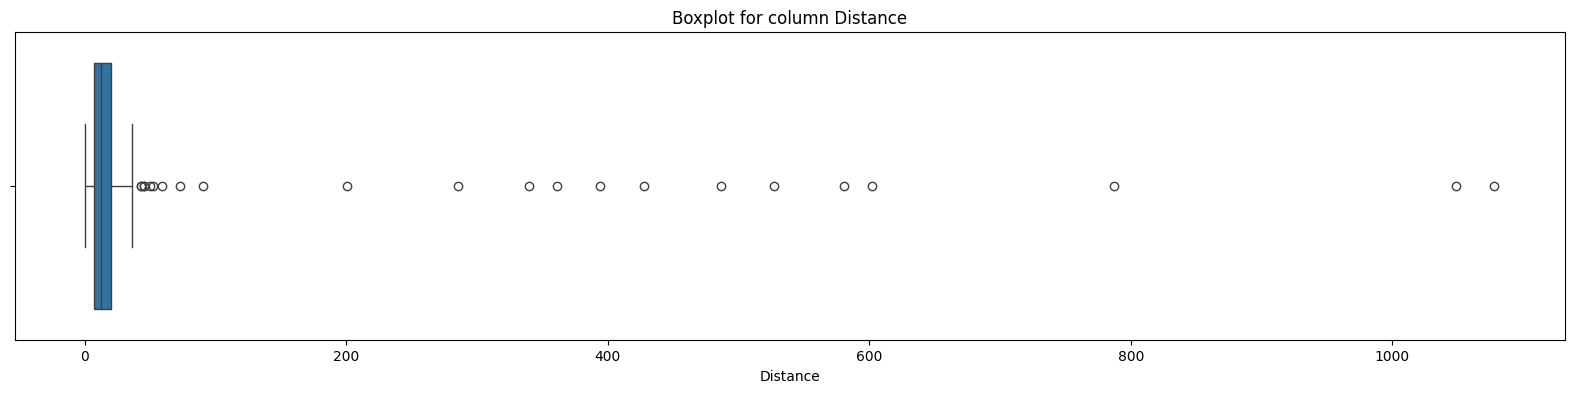

In [368]:
plt.figure(figsize=(20, 4))
sns.boxplot(x=d['Distance'])
plt.title('Boxplot for column Distance')
plt.show()

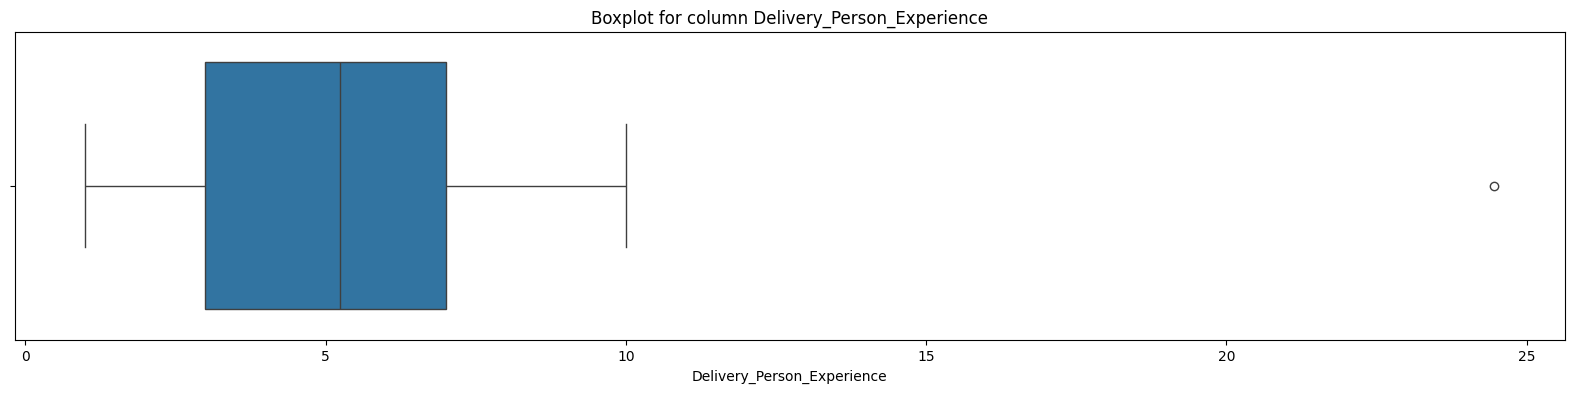

In [369]:
plt.figure(figsize=(20, 4))
sns.boxplot(x=d['Delivery_Person_Experience'])
plt.title('Boxplot for column Delivery_Person_Experience')
plt.show()

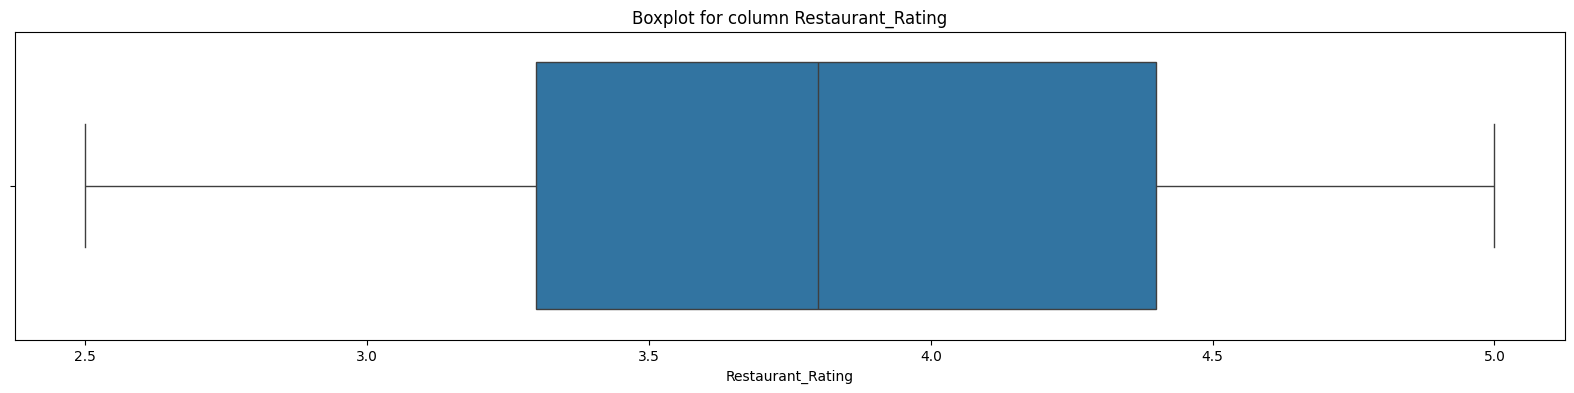

In [370]:
plt.figure(figsize=(20, 4))
sns.boxplot(x=d['Restaurant_Rating'])
plt.title('Boxplot for column Restaurant_Rating')
plt.show()

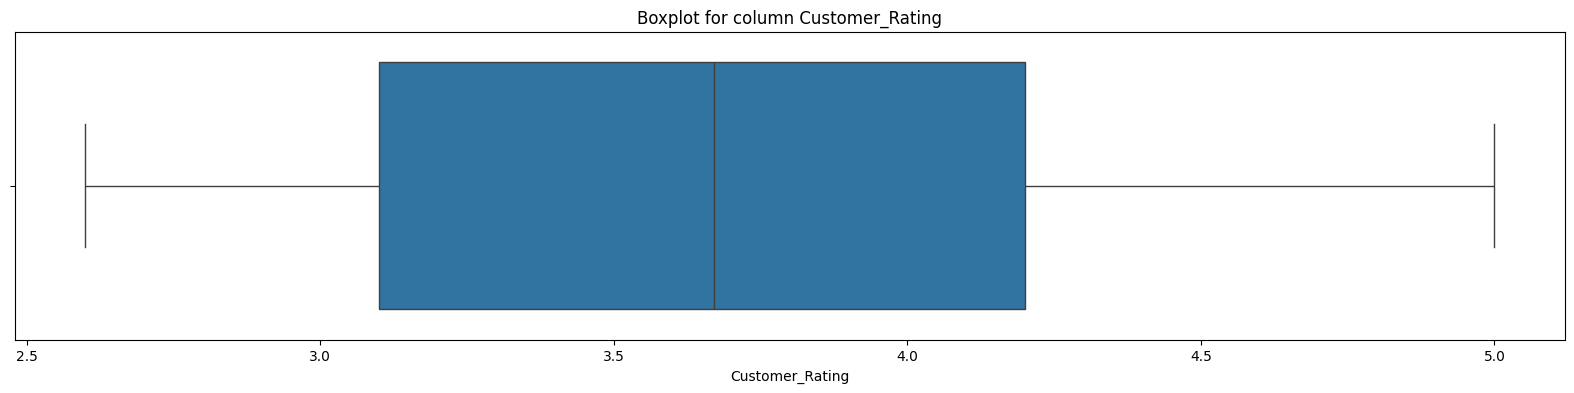

In [371]:
plt.figure(figsize=(20, 4))
sns.boxplot(x=d['Customer_Rating'])
plt.title('Boxplot for column Customer_Rating')
plt.show()

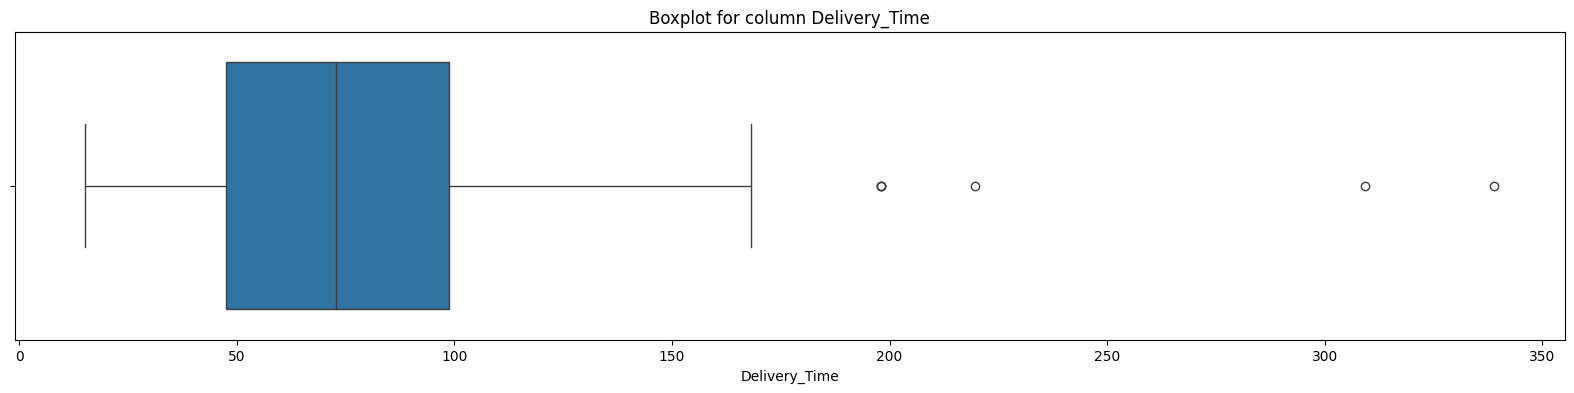

In [372]:
plt.figure(figsize=(20, 4))
sns.boxplot(x=d['Delivery_Time'])
plt.title('Boxplot for column Delivery_Time')
plt.show()

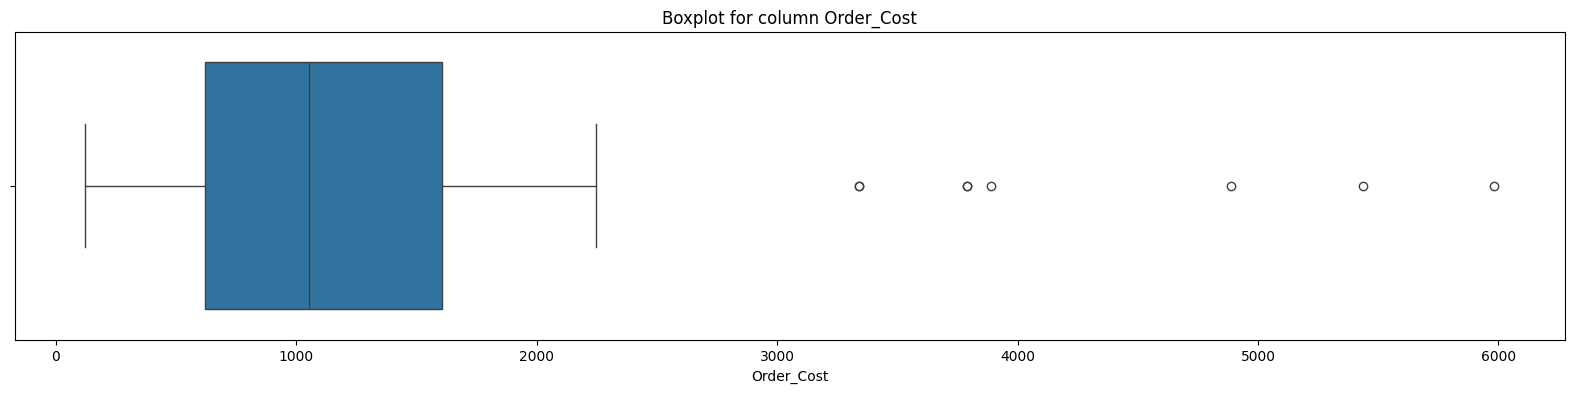

In [373]:
plt.figure(figsize=(20, 4))
sns.boxplot(x=d['Order_Cost'])
plt.title('Boxplot for column Order_Cost')
plt.show()

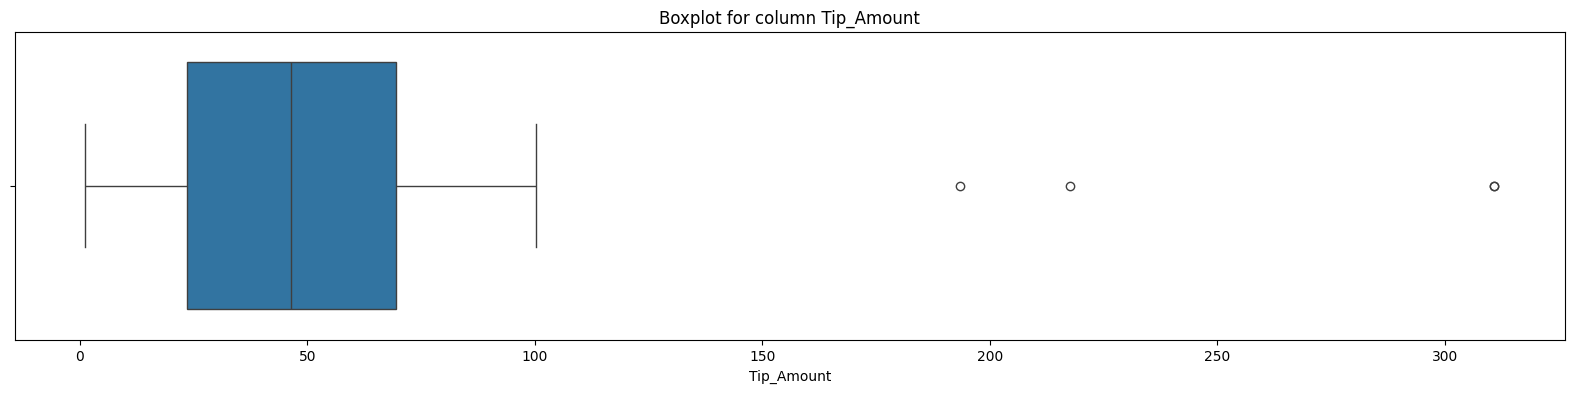

In [374]:
plt.figure(figsize=(20, 4))
sns.boxplot(x=d['Tip_Amount'])
plt.title('Boxplot for column Tip_Amount')
plt.show()

In [389]:
def plot_distribution_with_statistics(column, mean_val, median_val, mode_val):
    data = d[column]
    
    plt.figure(figsize=(10, 6))
    plt.hist(data, bins=30, alpha=0.6, color='skyblue', edgecolor='black', density=True)
    
    kde = gaussian_kde(data)
    x_vals = np.linspace(min(data), max(data), 300)
    plt.plot(x_vals, kde(x_vals), color='blue', label='KDE')
    
    plt.axvline(mean_val, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_val:.2f}')
    plt.axvline(median_val, color='green', linestyle='dotted', linewidth=2, label=f'Median: {median_val:.2f}')
    plt.axvline(mode_val, color='orange', linestyle='solid', linewidth=2, label=f'Mode: {mode_val:.2f}')
    
    plt.title(f'Distribution and Mean, Median, Mode for {column}')
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.legend()
    plt.show()
    
    if mean_val == median_val == mode_val:
        skewness = 'Symmetric'
    elif mean_val > median_val > mode_val:
        skewness = 'Positively skewed (right-skewed)'
    elif mean_val < median_val < mode_val:
        skewness = 'Negatively skewed (left-skewed)'
    else:
        skewness = 'Asymmetric distribution but unclear skew direction'
    
    return skewness

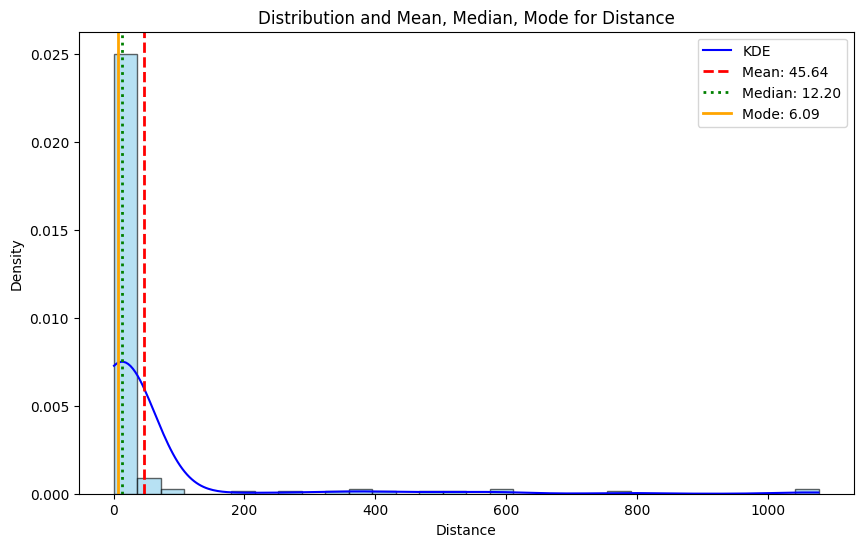

The distribution of Distance is Positively skewed (right-skewed).


In [390]:
skewness_description = plot_distribution_with_statistics('Distance', dist_mean, dist_median, dist_mode)
print(f'The distribution of Distance is {skewness_description}.')

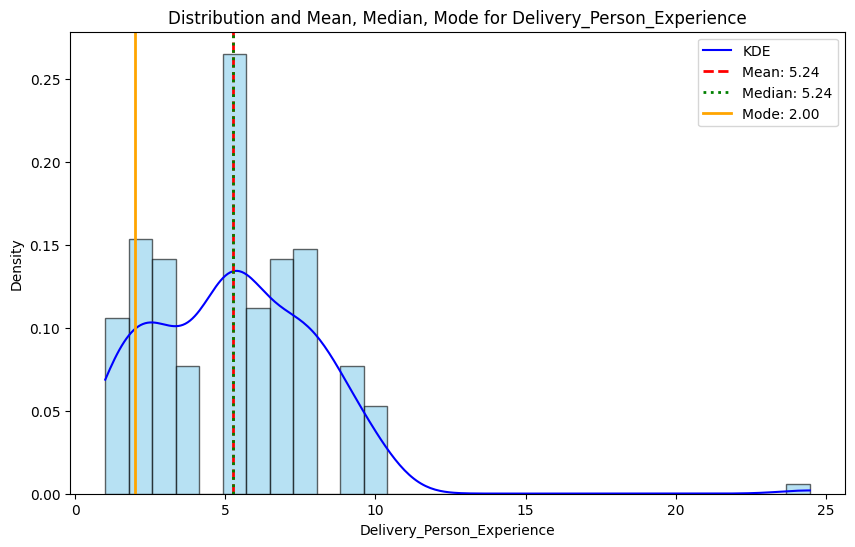

The distribution of Distance is Positively skewed (right-skewed).


In [ ]:
skewness_description = plot_distribution_with_statistics('Delivery_Person_Experience', delivery_person_experience_mean, delivery_person_experience_median, delivery_person_experience_mode)
print(f'The distribution of Delivery Person Experience is {skewness_description}.')

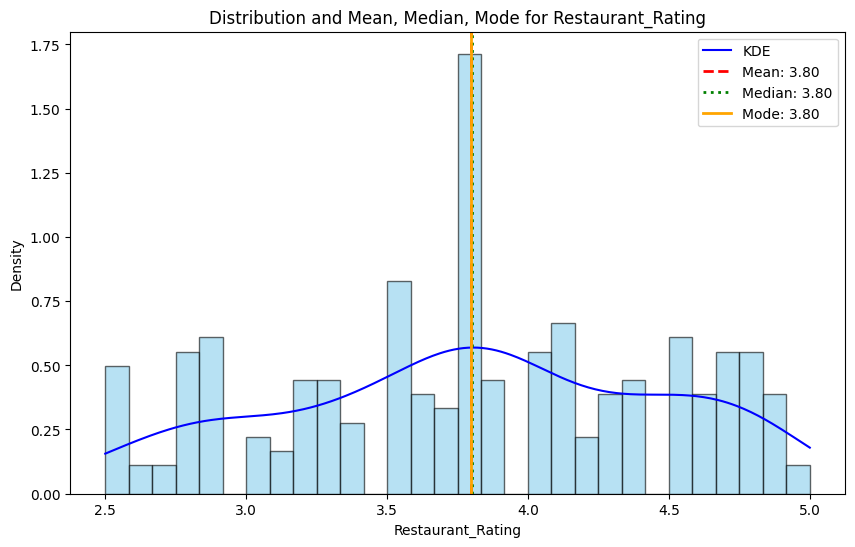

The distribution of Restaurant Rating is Asymmetric distribution but unclear skew direction.


In [397]:
skewness_description = plot_distribution_with_statistics('Restaurant_Rating', restaurant_rating_mean, restaurant_rating_median, restaurant_rating_mode)
print(f'The distribution of Restaurant Rating is {skewness_description}.')

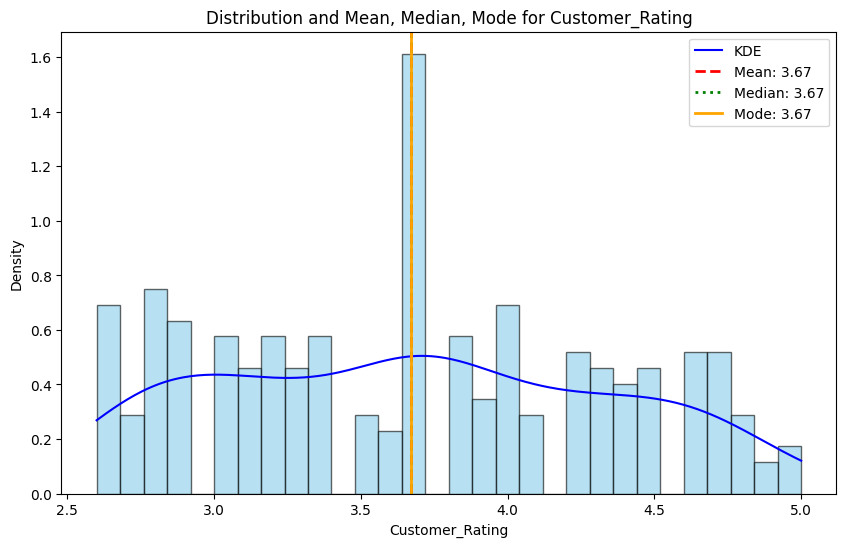

The distribution of Customer Rating is Symmetric.


In [398]:
skewness_description = plot_distribution_with_statistics('Customer_Rating', customer_rating_mean, customer_rating_median, customer_rating_mode)
print(f'The distribution of Customer Rating is {skewness_description}.')

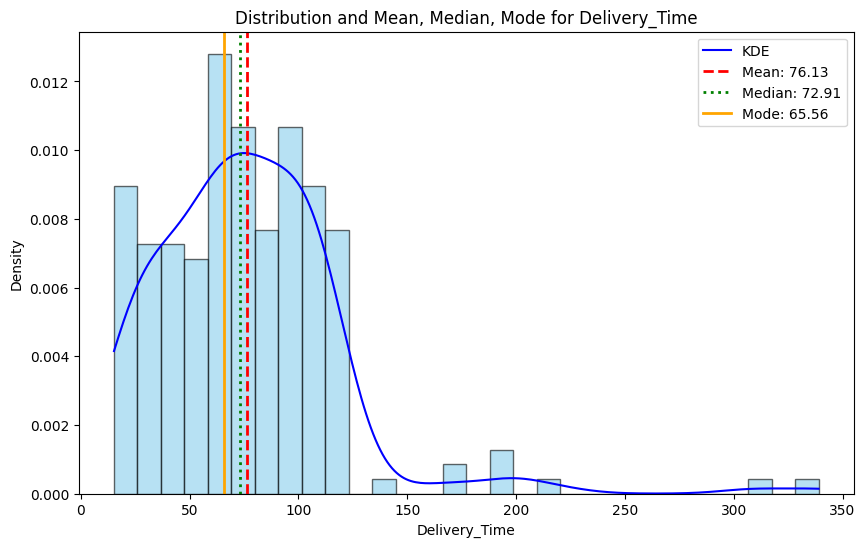

The distribution of Delivery Time is Positively skewed (right-skewed).


In [399]:
skewness_description = plot_distribution_with_statistics('Delivery_Time', Delivery_Time_mean, Delivery_Time_median, Delivery_Time_mode)
print(f'The distribution of Delivery Time is {skewness_description}.')

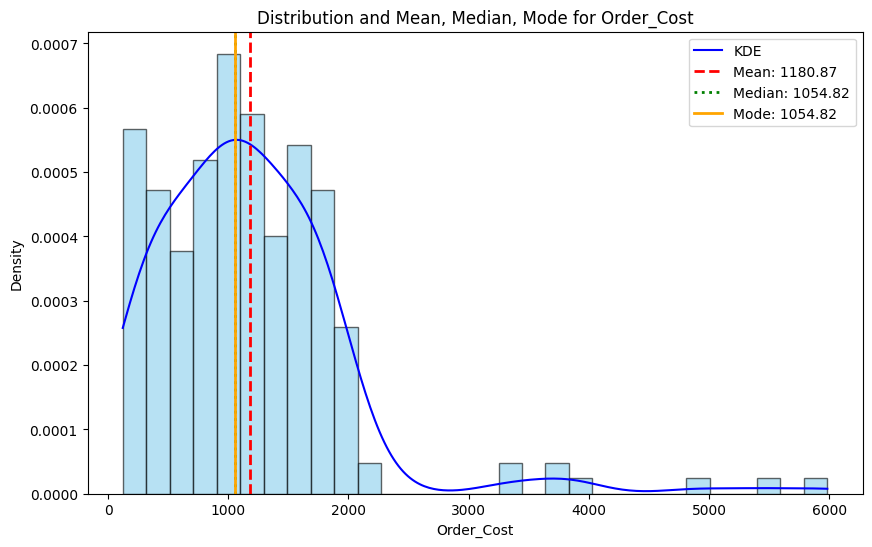

The distribution of Order Cost is Asymmetric distribution but unclear skew direction.


In [400]:
skewness_description = plot_distribution_with_statistics('Order_Cost', Order_Cost_mean, Order_Cost_median, Order_Cost_median)
print(f'The distribution of Order Cost is {skewness_description}.')

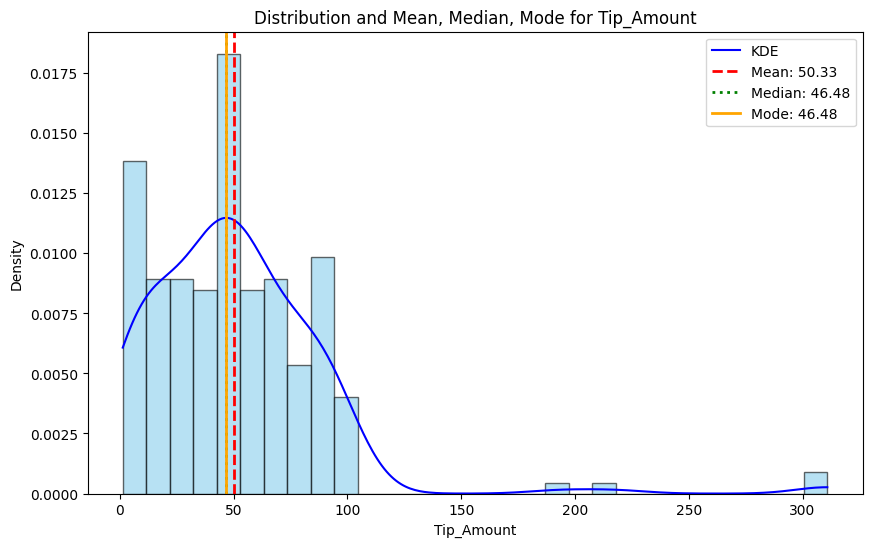

The distribution of Tip RaAmountting is Asymmetric distribution but unclear skew direction.


In [401]:
skewness_description = plot_distribution_with_statistics('Tip_Amount', Tip_Amount_mean, Tip_Amount_median, Tip_Amount_mode)
print(f'The distribution of Tip RaAmountting is {skewness_description}.')

## ✅ Conclusion
The *Food Delivery Time Prediction Dataset* is a valuable resource in the *logistics and food delivery sector*.  
It helps improve delivery operations, reduce costs, and enhance customer satisfaction through *predictive analytics*.

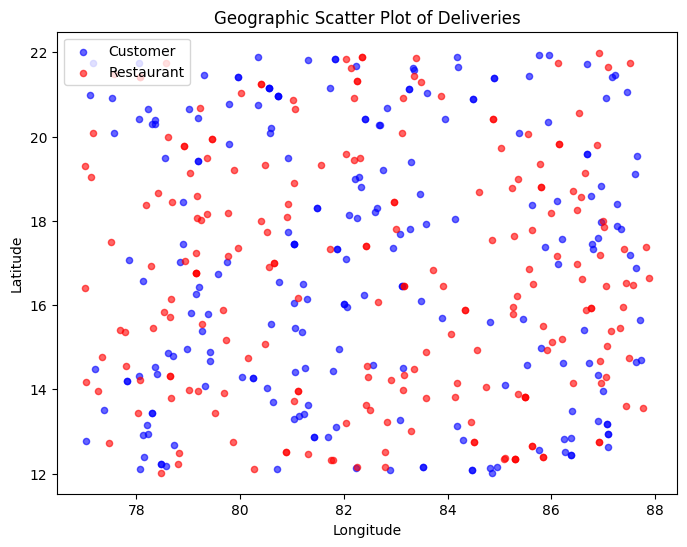

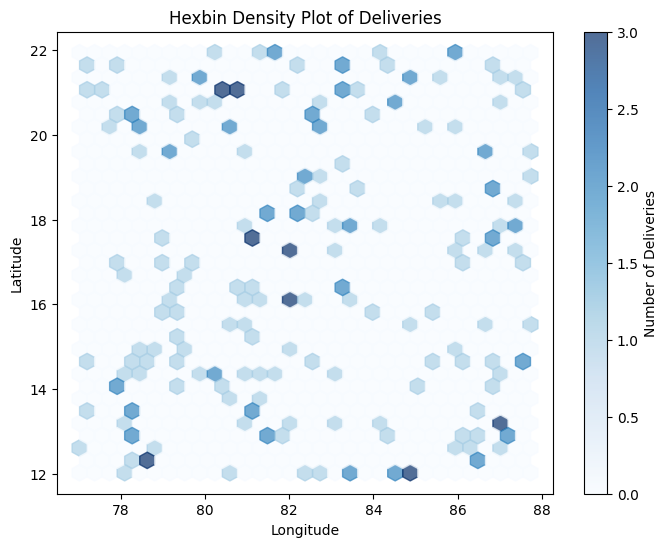

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV
df = pd.read_csv('Food_Delivery_Time_Prediction_without_null_values.csv')

# Function to clean and split "(lat, lon)" strings
def split_lat_long(s):
    s = s.strip().replace('(', '').replace(')', '')  # remove parenthesis and whitespace
    lat, lon = s.split(',')
    return float(lat), float(lon)

# Apply to 'Customer_Location'
df[['cust_lat', 'cust_long']] = df['Customer_Location'].apply(lambda x: pd.Series(split_lat_long(x)))

# Apply to 'Restaurant_Location'
df[['rest_lat', 'rest_long']] = df['Restaurant_Location'].apply(lambda x: pd.Series(split_lat_long(x)))

# Plot as before
plt.figure(figsize=(8,6))
plt.scatter(df['cust_long'], df['cust_lat'], s=20, alpha=0.6, label='Customer', c='blue')
plt.scatter(df['rest_long'], df['rest_lat'], s=20, alpha=0.6, label='Restaurant', c='red')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Scatter Plot of Deliveries')
plt.legend()
plt.show()

plt.figure(figsize=(8,6))
plt.hexbin(df['cust_long'], df['cust_lat'], gridsize=30, cmap='Blues', alpha=0.7)
plt.colorbar(label='Number of Deliveries')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Hexbin Density Plot of Deliveries')
plt.show()
